# Mutual Fund Performance Analytics

This notebook builds a reproducible 40-fund scorecard from daily NAV data and compares the leading funds with Nifty 50 and Nifty 100.

## Universe and conventions

- The repository contains only six schemes, and five supplied scheme codes do not match their labels. No authoritative 40-scheme list is present.
- The analysis therefore defines the universe as the **40 largest five-year-eligible Direct Growth funds across the Large Cap and Flexi Cap categories**, ranked by the current AUM field returned by Kuvera. Passive/index/FoF, bonus, and long-short variants are excluded.
- Fund metadata and expense ratios: Kuvera public API. Historical NAVs: MFAPI (AMFI scheme codes). Benchmarks: Yahoo Finance chart endpoint for Nifty 50 (^NSEI) and Nifty 100 (^CNX100).
- Risk-free rate is 6.5% annual, converted to an effective daily rate. Sharpe and Sortino use a 252-trading-day convention.
- Sharpe, Sortino, alpha, beta, and tracking error use trailing three years. Maximum drawdown uses trailing five years. CAGR uses the nearest available NAV on or before each anniversary.
- Nifty series are price indices. Growth-plan NAVs reflect reinvested fund income, so the benchmark chart is useful but not a total-return-index comparison.


In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.stats import linregress
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

EXPECTED_FUNDS = 40
FUND_POOL_SIZE = 60
FUND_CATEGORIES = ("Large Cap Fund", "Flexi Cap Fund")
ANNUAL_TRADING_DAYS = 252
RISK_FREE_ANNUAL = 0.065
RISK_FREE_DAILY = (1 + RISK_FREE_ANNUAL) ** (1 / ANNUAL_TRADING_DAYS) - 1
RISK_WINDOW_YEARS = 3
DRAWDOWN_WINDOW_YEARS = 5
MAX_WORKERS = 8

ROOT = Path.cwd()
SCORECARD_PATH = ROOT / "fund_scorecard.csv"
ALPHA_BETA_PATH = ROOT / "alpha_beta.csv"
CHART_PATH = ROOT / "benchmark_comparison.png"

KUVERA_LIST_URL = "https://api.kuvera.in/mf/api/v4/fund_schemes/list.json"
KUVERA_DETAIL_URL = "https://api.kuvera.in/mf/api/v5/fund_schemes/{code}.json"
MFAPI_LIST_URL = "https://api.mfapi.in/mf"
MFAPI_NAV_URL = "https://api.mfapi.in/mf/{scheme_code}"
YAHOO_CHART_URL = "https://query1.finance.yahoo.com/v8/finance/chart/{symbol}"

print(f"Annual risk-free rate: {RISK_FREE_ANNUAL:.2%}")
print(f"Effective daily risk-free rate: {RISK_FREE_DAILY:.8%}")


Annual risk-free rate: 6.50%
Effective daily risk-free rate: 0.02499312%


In [2]:
def fetch_json(url, params=None, retries=4, timeout=90):
    headers = {"User-Agent": "Mozilla/5.0 (compatible; PerformanceAnalytics/1.0)"}
    last_error = None
    for attempt in range(retries):
        try:
            response = requests.get(url, params=params, headers=headers, timeout=timeout)
            response.raise_for_status()
            return response.json()
        except Exception as exc:
            last_error = exc
            if attempt < retries - 1:
                time.sleep(1.5 * (2 ** attempt))
    raise RuntimeError(f"Failed after {retries} attempts: {url}") from last_error


def fetch_kuvera_detail(candidate):
    payload = fetch_json(KUVERA_DETAIL_URL.format(code=candidate["kuvera_code"]))
    if not isinstance(payload, list) or not payload:
        raise ValueError(f"Unexpected Kuvera response for {candidate['kuvera_code']}")
    detail = payload[0]
    return {
        **candidate,
        "scheme_name": detail.get("name", candidate["scheme_name"]),
        "isin": detail.get("ISIN"),
        "fund_house": detail.get("fund_name"),
        "start_date": detail.get("start_date"),
        "expense_ratio_pct": pd.to_numeric(detail.get("expense_ratio"), errors="coerce"),
        "expense_ratio_date": detail.get("expense_ratio_date"),
        "aum_source_value": pd.to_numeric(detail.get("aum"), errors="coerce"),
        "maturity_type": detail.get("maturity_type"),
        "direct": detail.get("direct"),
        "plan": detail.get("plan"),
        "latest_nav_date": (detail.get("nav") or {}).get("date"),
    }


kuvera_catalog = fetch_json(KUVERA_LIST_URL)
mfapi_catalog = fetch_json(MFAPI_LIST_URL)

mfapi_by_isin = {}
for item in mfapi_catalog:
    for isin_field in ("isinGrowth", "isinDivReinvestment"):
        isin = item.get(isin_field)
        if isin:
            mfapi_by_isin.setdefault(isin, item)

candidates = []
for category in FUND_CATEGORIES:
    category_tree = kuvera_catalog.get("Equity", {}).get(category, {})
    for amc_key, plans in category_tree.items():
        for plan in plans:
            name = str(plan.get("n", ""))
            if plan.get("re") == "Z" and "Growth" in name and "Direct Plan" in name:
                candidates.append({
                    "category": category,
                    "amc_key": amc_key,
                    "kuvera_code": plan.get("c"),
                    "scheme_name": name,
                })

details, detail_errors = [], []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futures = {pool.submit(fetch_kuvera_detail, row): row for row in candidates}
    for future in as_completed(futures):
        try:
            details.append(future.result())
        except Exception as exc:
            detail_errors.append((futures[future]["kuvera_code"], str(exc)))

universe_candidates = pd.DataFrame(details)
universe_candidates["start_date"] = pd.to_datetime(universe_candidates["start_date"], errors="coerce")
universe_candidates["scheme_code"] = universe_candidates["isin"].map(
    lambda x: mfapi_by_isin.get(x, {}).get("schemeCode")
)
universe_candidates["mfapi_scheme_name"] = universe_candidates["isin"].map(
    lambda x: mfapi_by_isin.get(x, {}).get("schemeName")
)

cutoff = pd.Timestamp.today().normalize() - pd.DateOffset(years=5) - pd.Timedelta(days=30)
exclusion_pattern = r"Index|Passive|FoF|Fund of Fund|Bonus|Long Short"
eligible = universe_candidates.loc[
    universe_candidates["scheme_code"].notna()
    & universe_candidates["expense_ratio_pct"].notna()
    & universe_candidates["aum_source_value"].notna()
    & universe_candidates["start_date"].le(cutoff)
    & universe_candidates["maturity_type"].eq("Open Ended")
    & universe_candidates["direct"].eq("Y")
    & universe_candidates["plan"].eq("GROWTH")
    & ~universe_candidates["scheme_name"].str.contains(exclusion_pattern, case=False, regex=True, na=False)
].copy()

eligible["scheme_code"] = eligible["scheme_code"].astype(int)
eligible = eligible.sort_values(["aum_source_value", "scheme_name"], ascending=[False, True])
fund_pool = eligible.drop_duplicates("scheme_code").head(FUND_POOL_SIZE).reset_index(drop=True)

assert len(fund_pool) >= EXPECTED_FUNDS, (
    f"Only {len(fund_pool)} eligible fund candidates were available; expected at least {EXPECTED_FUNDS}. "
    f"Kuvera detail errors: {detail_errors[:3]}"
)
assert fund_pool["scheme_code"].is_unique

print(f"Candidates discovered: {len(candidates)}")
print(f"Eligible mature direct-growth funds: {len(eligible)}")
print(f"Candidate pool sent to NAV-history validation: {len(fund_pool)}")
display(fund_pool.head(10)[["scheme_code", "scheme_name", "category", "fund_house", "start_date", "expense_ratio_pct", "expense_ratio_date"]])


Candidates discovered: 83
Eligible mature direct-growth funds: 50
Candidate pool sent to NAV-history validation: 50


,scheme_code,scheme_name,category,fund_house,start_date,expense_ratio_pct,expense_ratio_date
0,122639,Parag Parikh Flexi Cap Growth Direct Plan,Flexi Cap Fund,PPFAS Mutual Fund,2013-05-24,0.5300,2026-05-31
1,118955,HDFC Flexicap Growth Direct Plan,Flexi Cap Fund,HDFC Mutual Fund,2013-01-01,0.6800,2026-05-31
2,120586,ICICI Prudential Large Cap Growth Direct Plan,Large Cap Fund,ICICI Prudential Mutual Fund,2013-01-01,0.7200,2026-05-31
3,120166,Kotak Flexicap Growth Direct Plan,Flexi Cap Fund,Kotak Mutual Fund,2013-01-01,0.5900,2026-05-31
4,119598,SBI Large Cap Growth Direct Plan,Large Cap Fund,SBI Mutual Fund,2013-01-01,0.7900,2026-05-31
5,118632,Nippon India Large Cap Growth Direct Plan,Large Cap Fund,Nippon India Mutual Fund,2013-01-01,0.5800,2026-05-31
6,119018,HDFC Large Cap Growth Direct Plan,Large Cap Fund,HDFC Mutual Fund,2013-01-01,0.9900,2026-05-31
7,118825,Mirae Asset Large Cap Growth Direct Plan,Large Cap Fund,Mirae Asset Mutual Fund,2013-01-01,0.4900,2026-05-31
8,120465,Axis Large Cap Growth Direct Plan,Large Cap Fund,AXIS Mutual Fund,2013-01-01,0.7500,2026-05-31
9,119528,Aditya Birla Sun Life Large Cap Growth Direct ...,Large Cap Fund,Aditya Birla Sun Life Mutual Fund,2013-01-01,0.8100,2026-05-31


In [3]:
def fetch_fund_nav(row):
    payload = fetch_json(MFAPI_NAV_URL.format(scheme_code=int(row.scheme_code)))
    data = pd.DataFrame(payload.get("data", []))
    if data.empty:
        raise ValueError(f"No NAV history for {row.scheme_code}")
    data["date"] = pd.to_datetime(data["date"], dayfirst=True, errors="coerce")
    data["nav"] = pd.to_numeric(data["nav"], errors="coerce")
    data = data.dropna(subset=["date", "nav"]).loc[lambda x: x["nav"] > 0]
    data = data.drop_duplicates("date", keep="last").sort_values("date")
    data["scheme_code"] = int(row.scheme_code)
    data["scheme_name"] = row.scheme_name
    return data[["date", "scheme_code", "scheme_name", "nav"]]


nav_frames, nav_errors = [], []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futures = {
        pool.submit(fetch_fund_nav, row): int(row.scheme_code)
        for row in fund_pool.itertuples(index=False)
    }
    for future in as_completed(futures):
        try:
            nav_frames.append(future.result())
        except Exception as exc:
            nav_errors.append((futures[future], str(exc)))

if nav_errors:
    raise RuntimeError(f"NAV download failures: {nav_errors}")

nav_pool = pd.concat(nav_frames, ignore_index=True).sort_values(["scheme_code", "date"])
pool_latest_dates = nav_pool.groupby("scheme_code")["date"].max()
pool_earliest_dates = nav_pool.groupby("scheme_code")["date"].min()
fresh_cutoff = pool_latest_dates.max() - pd.Timedelta(days=7)
history_cutoff = pool_latest_dates.max() - pd.DateOffset(years=5) - pd.Timedelta(days=7)
history_eligible_codes = pool_latest_dates.index[
    pool_latest_dates.ge(fresh_cutoff) & pool_earliest_dates.le(history_cutoff)
]

fund_universe = fund_pool.loc[fund_pool["scheme_code"].isin(history_eligible_codes)].head(EXPECTED_FUNDS).reset_index(drop=True)
assert len(fund_universe) == EXPECTED_FUNDS, (
    f"Only {len(fund_universe)} funds have fresh data and a complete five-year NAV history."
)

nav_history = nav_pool.loc[nav_pool["scheme_code"].isin(fund_universe["scheme_code"])].copy()
latest_dates = nav_history.groupby("scheme_code")["date"].max()
earliest_dates = nav_history.groupby("scheme_code")["date"].min()
AS_OF_DATE = latest_dates.min()
stale_days = (latest_dates.max() - latest_dates).dt.days

assert nav_history["scheme_code"].nunique() == EXPECTED_FUNDS
assert stale_days.max() <= 7, f"At least one fund is stale by {stale_days.max()} days."
assert earliest_dates.le(AS_OF_DATE - pd.DateOffset(years=5)).all()

nav_history = nav_history.loc[nav_history["date"] <= AS_OF_DATE].copy()
print(f"Common fund as-of date: {AS_OF_DATE.date()}")
print(f"NAV rows: {len(nav_history):,}")
print(f"History coverage: {earliest_dates.min().date()} to {latest_dates.max().date()}")
display(fund_universe[["scheme_code", "scheme_name", "category", "fund_house", "start_date", "expense_ratio_pct", "expense_ratio_date"]])


Common fund as-of date: 2026-06-25
NAV rows: 124,786
History coverage: 2013-01-01 to 2026-06-25


,scheme_code,scheme_name,category,fund_house,start_date,expense_ratio_pct,expense_ratio_date
0,122639,Parag Parikh Flexi Cap Growth Direct Plan,Flexi Cap Fund,PPFAS Mutual Fund,2013-05-24,0.5300,2026-05-31
1,118955,HDFC Flexicap Growth Direct Plan,Flexi Cap Fund,HDFC Mutual Fund,2013-01-01,0.6800,2026-05-31
2,120586,ICICI Prudential Large Cap Growth Direct Plan,Large Cap Fund,ICICI Prudential Mutual Fund,2013-01-01,0.7200,2026-05-31
3,120166,Kotak Flexicap Growth Direct Plan,Flexi Cap Fund,Kotak Mutual Fund,2013-01-01,0.5900,2026-05-31
4,119598,SBI Large Cap Growth Direct Plan,Large Cap Fund,SBI Mutual Fund,2013-01-01,0.7900,2026-05-31
5,118632,Nippon India Large Cap Growth Direct Plan,Large Cap Fund,Nippon India Mutual Fund,2013-01-01,0.5800,2026-05-31
6,119018,HDFC Large Cap Growth Direct Plan,Large Cap Fund,HDFC Mutual Fund,2013-01-01,0.9900,2026-05-31
7,118825,Mirae Asset Large Cap Growth Direct Plan,Large Cap Fund,Mirae Asset Mutual Fund,2013-01-01,0.4900,2026-05-31
8,120465,Axis Large Cap Growth Direct Plan,Large Cap Fund,AXIS Mutual Fund,2013-01-01,0.7500,2026-05-31
9,119528,Aditya Birla Sun Life Large Cap Growth Direct ...,Large Cap Fund,Aditya Birla Sun Life Mutual Fund,2013-01-01,0.8100,2026-05-31


## 1. Daily returns and distribution validation

Returns use only reported NAV dates; weekends and holidays are not forward-filled. This avoids artificially adding zero-return observations while retaining the requested 252-day annualization convention.


In [4]:
nav_history["daily_return"] = nav_history.groupby("scheme_code", sort=False)["nav"].pct_change(fill_method=None)
daily_returns = nav_history.dropna(subset=["daily_return"]).copy()

distribution_by_fund = daily_returns.groupby(["scheme_code", "scheme_name"])["daily_return"].agg(
    observations="count",
    mean="mean",
    std="std",
    minimum="min",
    p01=lambda x: x.quantile(0.01),
    median="median",
    p99=lambda x: x.quantile(0.99),
    maximum="max",
).reset_index()

distribution_flags = distribution_by_fund.loc[
    (distribution_by_fund["observations"] < 1000)
    | (distribution_by_fund["std"] <= 0)
    | (distribution_by_fund["std"] > 0.05)
    | (distribution_by_fund["minimum"] < -0.25)
    | (distribution_by_fund["maximum"] > 0.25)
]

aggregate_quantiles = daily_returns["daily_return"].quantile([0, .001, .01, .5, .99, .999, 1]).to_frame("daily_return")
aggregate_quantiles["daily_return_pct"] = aggregate_quantiles["daily_return"] * 100

assert np.isfinite(daily_returns["daily_return"]).all()
assert distribution_by_fund["scheme_code"].nunique() == EXPECTED_FUNDS

print(f"Valid daily returns: {len(daily_returns):,}")
print(f"Distribution flags: {len(distribution_flags)}")
display(aggregate_quantiles[["daily_return_pct"]])
if len(distribution_flags):
    display(distribution_flags)
else:
    print("Distribution validation passed: no insufficient-history, zero-volatility, >5% daily-volatility, or +/-25% single-day flags.")


Valid daily returns: 124,746
Distribution flags: 0


,daily_return_pct
0.0000,-14.3662
0.0010,-6.4800
0.0100,-2.7430
0.5000,0.1010
0.9900,2.3952
0.9990,4.9479
1.0000,9.2125


Distribution validation passed: no insufficient-history, zero-volatility, >5% daily-volatility, or +/-25% single-day flags.


## 2. Trailing 1-, 3-, and 5-year CAGR comparison

In [5]:
def trailing_cagr(group, years, as_of=AS_OF_DATE):
    series = group.set_index("date")["nav"].sort_index()
    ending = series.loc[:as_of]
    target = as_of - pd.DateOffset(years=years)
    starting = series.loc[:target]
    if ending.empty or starting.empty:
        return np.nan, pd.NaT, pd.NaT
    start_date, start_nav = starting.index[-1], starting.iloc[-1]
    end_date, end_nav = ending.index[-1], ending.iloc[-1]
    return (end_nav / start_nav) ** (1 / years) - 1, start_date, end_date


cagr_rows = []
for (scheme_code, scheme_name), group in nav_history.groupby(["scheme_code", "scheme_name"]):
    row = {"scheme_code": scheme_code, "scheme_name": scheme_name}
    for years in (1, 3, 5):
        value, start_date, end_date = trailing_cagr(group, years)
        row[f"cagr_{years}y_pct"] = value * 100
        row[f"cagr_{years}y_start"] = start_date
    row["as_of_date"] = AS_OF_DATE
    cagr_rows.append(row)

cagr_table = pd.DataFrame(cagr_rows)
assert cagr_table[["cagr_1y_pct", "cagr_3y_pct", "cagr_5y_pct"]].notna().all().all()
display(cagr_table.sort_values("cagr_3y_pct", ascending=False)[[
    "scheme_name", "cagr_1y_pct", "cagr_3y_pct", "cagr_5y_pct", "as_of_date"
]])


,scheme_name,cagr_1y_pct,cagr_3y_pct,cagr_5y_pct,as_of_date
39,Bank Of India Flexi Cap Growth Direct Plan,9.2986,23.0477,18.1562,2026-06-25
31,Quant Flexi Cap Growth Direct Plan,13.5493,20.5259,17.1441,2026-06-25
33,Motilal Oswal Flexi Cap Growth Direct Plan,-6.2452,19.0473,12.4768,2026-06-25
9,HDFC Flexicap Growth Direct Plan,2.1451,18.7959,18.4869,2026-06-25
19,HSBC Flexi Cap Growth Direct Plan,3.3061,18.5452,14.8560,2026-06-25
26,JM Flexicap Growth Direct Plan,0.5819,18.5074,17.7115,2026-06-25
27,Aditya Birla Sun Life Flexi Cap Growth Direct ...,5.7747,17.5586,13.3473,2026-06-25
35,Edelweiss Flexi Cap Growth Direct Plan,1.9802,17.2185,15.0960,2026-06-25
24,Invesco India Largecap Growth Direct Plan,2.2376,16.2062,14.2023,2026-06-25
5,Franklin India Flexi Cap Growth Direct Plan,-2.3371,15.9289,14.4152,2026-06-25


## 3. Sharpe, Sortino, and maximum drawdown

In [6]:
risk_start = AS_OF_DATE - pd.DateOffset(years=RISK_WINDOW_YEARS)
drawdown_start = AS_OF_DATE - pd.DateOffset(years=DRAWDOWN_WINDOW_YEARS)


def max_drawdown_stats(group, start_date=drawdown_start, end_date=AS_OF_DATE):
    series = group.loc[group["date"].between(start_date, end_date)].set_index("date")["nav"].sort_index()
    running_max = series.cummax()
    drawdown = series / running_max - 1
    trough_date = drawdown.idxmin()
    peak_date = series.loc[:trough_date].idxmax()
    return drawdown.min(), peak_date, trough_date


risk_rows = []
for (scheme_code, scheme_name), group in nav_history.groupby(["scheme_code", "scheme_name"]):
    returns = group.loc[group["date"].between(risk_start, AS_OF_DATE), "daily_return"].dropna()
    volatility = returns.std(ddof=1)
    downside = returns.loc[returns < 0]
    downside_deviation = downside.std(ddof=1)
    sharpe = ((returns.mean() - RISK_FREE_DAILY) / volatility) * np.sqrt(ANNUAL_TRADING_DAYS)
    sortino = ((returns.mean() - RISK_FREE_DAILY) / downside_deviation) * np.sqrt(ANNUAL_TRADING_DAYS)
    max_dd, peak_date, trough_date = max_drawdown_stats(group)
    risk_rows.append({
        "scheme_code": scheme_code,
        "scheme_name": scheme_name,
        "risk_observations": len(returns),
        "annualized_volatility_pct": volatility * np.sqrt(ANNUAL_TRADING_DAYS) * 100,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown_pct": max_dd * 100,
        "drawdown_peak_date": peak_date,
        "drawdown_trough_date": trough_date,
    })

risk_metrics = pd.DataFrame(risk_rows)
risk_metrics["sharpe_rank"] = risk_metrics["sharpe_ratio"].rank(ascending=False, method="min").astype(int)
risk_metrics["sortino_rank"] = risk_metrics["sortino_ratio"].rank(ascending=False, method="min").astype(int)

assert risk_metrics["scheme_code"].nunique() == EXPECTED_FUNDS
display(risk_metrics.sort_values("sharpe_ratio", ascending=False)[[
    "scheme_name", "sharpe_ratio", "sharpe_rank", "sortino_ratio", "sortino_rank",
    "annualized_volatility_pct", "max_drawdown_pct", "drawdown_peak_date", "drawdown_trough_date"
]])


,scheme_name,sharpe_ratio,sharpe_rank,sortino_ratio,sortino_rank,annualized_volatility_pct,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date
9,HDFC Flexicap Growth Direct Plan,1.0175,1,1.3296,1,11.8737,-13.3210,2026-01-06,2026-03-31
39,Bank Of India Flexi Cap Growth Direct Plan,0.9342,2,1.0471,6,17.7420,-23.7292,2024-12-11,2025-02-28
32,Parag Parikh Flexi Cap Growth Direct Plan,0.8823,3,1.2183,2,9.8113,-17.8669,2021-10-19,2022-06-17
31,Quant Flexi Cap Growth Direct Plan,0.8518,4,1.0775,4,16.7478,-24.7070,2024-09-27,2025-03-03
27,Aditya Birla Sun Life Flexi Cap Growth Direct ...,0.8412,5,1.0869,3,13.2983,-20.0383,2021-10-18,2022-06-20
19,HSBC Flexi Cap Growth Direct Plan,0.7940,6,0.9855,7,15.5885,-22.6681,2022-01-17,2022-06-20
26,JM Flexicap Growth Direct Plan,0.7867,7,0.9349,10,15.7240,-22.5753,2024-09-27,2026-03-31
33,Motilal Oswal Flexi Cap Growth Direct Plan,0.7755,8,1.0528,5,16.7614,-21.5488,2024-12-16,2026-03-23
35,Edelweiss Flexi Cap Growth Direct Plan,0.7602,9,0.9445,9,14.5229,-19.0265,2024-09-26,2025-02-28
5,Franklin India Flexi Cap Growth Direct Plan,0.7321,10,0.9315,11,13.3285,-17.6522,2022-01-17,2022-06-20


## 4. Benchmark data, alpha, beta, and tracking error

In [7]:
def fetch_yahoo_index(symbol, label, start_date, end_date):
    period1 = int(pd.Timestamp(start_date, tz="UTC").timestamp())
    period2 = int((pd.Timestamp(end_date, tz="UTC") + pd.Timedelta(days=2)).timestamp())
    payload = fetch_json(
        YAHOO_CHART_URL.format(symbol=requests.utils.quote(symbol, safe="")),
        params={"period1": period1, "period2": period2, "interval": "1d", "events": "history"},
    )
    result = payload["chart"]["result"][0]
    timestamps = pd.to_datetime(result["timestamp"], unit="s", utc=True).tz_convert(None).normalize()
    indicators = result["indicators"]
    adjusted = indicators.get("adjclose", [{}])[0].get("adjclose")
    close = adjusted if adjusted is not None else indicators["quote"][0]["close"]
    frame = pd.DataFrame({"date": timestamps, "level": close}).dropna().drop_duplicates("date")
    frame["benchmark"] = label
    frame["benchmark_return"] = frame["level"].pct_change(fill_method=None)
    return frame


benchmark_fetch_start = AS_OF_DATE - pd.DateOffset(years=DRAWDOWN_WINDOW_YEARS) - pd.Timedelta(days=10)
benchmarks = pd.concat([
    fetch_yahoo_index("^NSEI", "Nifty 50", benchmark_fetch_start, AS_OF_DATE),
    fetch_yahoo_index("^CNX100", "Nifty 100", benchmark_fetch_start, AS_OF_DATE),
], ignore_index=True)

nifty100_returns = benchmarks.loc[
    (benchmarks["benchmark"] == "Nifty 100")
    & benchmarks["date"].between(risk_start, AS_OF_DATE),
    ["date", "benchmark_return"]
].dropna()

alpha_beta_rows = []
for (scheme_code, scheme_name), group in daily_returns.groupby(["scheme_code", "scheme_name"]):
    fund = group.loc[group["date"].between(risk_start, AS_OF_DATE), ["date", "daily_return"]]
    aligned = fund.merge(nifty100_returns, on="date", how="inner").dropna()
    regression = linregress(aligned["benchmark_return"], aligned["daily_return"])
    alpha_beta_rows.append({
        "scheme_code": scheme_code,
        "scheme_name": scheme_name,
        "benchmark": "Nifty 100 (^CNX100)",
        "period_start": aligned["date"].min(),
        "period_end": aligned["date"].max(),
        "observations": len(aligned),
        "alpha_annual_pct": regression.intercept * ANNUAL_TRADING_DAYS * 100,
        "beta": regression.slope,
        "r_squared": regression.rvalue ** 2,
        "p_value": regression.pvalue,
        "slope_std_error": regression.stderr,
    })

alpha_beta = pd.DataFrame(alpha_beta_rows).sort_values("alpha_annual_pct", ascending=False).reset_index(drop=True)
alpha_beta["alpha_rank"] = alpha_beta["alpha_annual_pct"].rank(ascending=False, method="min").astype(int)
alpha_beta.to_csv(ALPHA_BETA_PATH, index=False, date_format="%Y-%m-%d")


def tracking_error_for_fund(group, benchmark_name):
    benchmark_returns = benchmarks.loc[
        (benchmarks["benchmark"] == benchmark_name)
        & benchmarks["date"].between(risk_start, AS_OF_DATE),
        ["date", "benchmark_return"]
    ].dropna()
    fund = group.loc[group["date"].between(risk_start, AS_OF_DATE), ["date", "daily_return"]]
    aligned = fund.merge(benchmark_returns, on="date", how="inner").dropna()
    active_return = aligned["daily_return"] - aligned["benchmark_return"]
    return active_return.std(ddof=1) * np.sqrt(ANNUAL_TRADING_DAYS) * 100, len(aligned)


tracking_rows = []
for (scheme_code, scheme_name), group in daily_returns.groupby(["scheme_code", "scheme_name"]):
    row = {"scheme_code": scheme_code, "scheme_name": scheme_name}
    for benchmark_name, slug in (("Nifty 50", "nifty50"), ("Nifty 100", "nifty100")):
        te, observations = tracking_error_for_fund(group, benchmark_name)
        row[f"tracking_error_{slug}_pct"] = te
        row[f"tracking_observations_{slug}"] = observations
    tracking_rows.append(row)

tracking_error = pd.DataFrame(tracking_rows)

assert len(alpha_beta) == EXPECTED_FUNDS
assert alpha_beta[["alpha_annual_pct", "beta"]].notna().all().all()
display(alpha_beta.head(10))


,scheme_code,scheme_name,benchmark,period_start,period_end,observations,alpha_annual_pct,beta,r_squared,p_value,slope_std_error,alpha_rank
0,148404,Bank Of India Flexi Cap Growth Direct Plan,Nifty 100 (^CNX100),2023-06-26,2026-06-25,730,9.7538,1.1244,0.7519,0.0000,0.0239,1
1,118955,HDFC Flexicap Growth Direct Plan,Nifty 100 (^CNX100),2023-06-26,2026-06-25,730,8.6888,0.8330,0.9212,0.0000,0.0090,2
2,120843,Quant Flexi Cap Growth Direct Plan,Nifty 100 (^CNX100),2023-06-26,2026-06-25,730,7.7988,1.0674,0.7612,0.0000,0.0222,3
3,129046,Motilal Oswal Flexi Cap Growth Direct Plan,Nifty 100 (^CNX100),2023-06-26,2026-06-25,730,7.7468,1.0051,0.6730,0.0000,0.0260,4
4,122639,Parag Parikh Flexi Cap Growth Direct Plan,Nifty 100 (^CNX100),2023-06-26,2026-06-25,729,7.1593,0.6332,0.7775,0.0000,0.0126,5
5,120492,JM Flexicap Growth Direct Plan,Nifty 100 (^CNX100),2023-06-26,2026-06-25,730,6.8585,1.0376,0.8155,0.0000,0.0183,6
6,120564,Aditya Birla Sun Life Flexi Cap Growth Direct ...,Nifty 100 (^CNX100),2023-06-26,2026-06-25,730,6.4872,0.9423,0.9399,0.0000,0.0088,7
7,120046,HSBC Flexi Cap Growth Direct Plan,Nifty 100 (^CNX100),2023-06-26,2026-06-25,730,6.0230,1.0618,0.8692,0.0000,0.0153,8
8,140353,Edelweiss Flexi Cap Growth Direct Plan,Nifty 100 (^CNX100),2023-06-26,2026-06-25,730,5.4948,1.0246,0.9303,0.0000,0.0104,9
9,119250,DSP Large Cap Growth Direct Plan,Nifty 100 (^CNX100),2023-06-26,2026-06-25,730,5.0437,0.8483,0.9208,0.0000,0.0092,10


## 5. Composite fund scorecard

Each component is a percentile rank on a 0–100 scale. Higher CAGR, Sharpe, and alpha are better. Lower expense ratio and smaller drawdown magnitude are better. The composite follows the requested weights exactly: 30% / 25% / 20% / 15% / 10%. Exact composite ties are ordered by 3-year CAGR, Sharpe, alpha, lower expense ratio, smaller drawdown, and finally scheme name; this tie-break changes only display rank, not fund score.


In [8]:
scorecard = (
    fund_universe[["scheme_code", "scheme_name", "category", "fund_house", "expense_ratio_pct", "expense_ratio_date"]]
    .merge(cagr_table, on=["scheme_code", "scheme_name"], how="inner")
    .merge(risk_metrics, on=["scheme_code", "scheme_name"], how="inner")
    .merge(alpha_beta.drop(columns=["scheme_name"]), on="scheme_code", how="inner")
    .merge(tracking_error.drop(columns=["scheme_name"]), on="scheme_code", how="inner")
)


def percentile_score(series, higher_is_better=True):
    return series.rank(method="average", ascending=higher_is_better, pct=True) * 100


scorecard["return_3y_rank_score"] = percentile_score(scorecard["cagr_3y_pct"], True)
scorecard["sharpe_rank_score"] = percentile_score(scorecard["sharpe_ratio"], True)
scorecard["alpha_rank_score"] = percentile_score(scorecard["alpha_annual_pct"], True)
scorecard["expense_ratio_rank_score"] = percentile_score(scorecard["expense_ratio_pct"], False)
scorecard["max_drawdown_rank_score"] = percentile_score(scorecard["max_drawdown_pct"], True)

scorecard["fund_score"] = (
    0.30 * scorecard["return_3y_rank_score"]
    + 0.25 * scorecard["sharpe_rank_score"]
    + 0.20 * scorecard["alpha_rank_score"]
    + 0.15 * scorecard["expense_ratio_rank_score"]
    + 0.10 * scorecard["max_drawdown_rank_score"]
)
scorecard = scorecard.sort_values(
    ["fund_score", "cagr_3y_pct", "sharpe_ratio", "alpha_annual_pct", "expense_ratio_pct", "max_drawdown_pct", "scheme_name"],
    ascending=[False, False, False, False, True, False, True],
).reset_index(drop=True)
scorecard["overall_rank"] = np.arange(1, len(scorecard) + 1)

column_order = [
    "overall_rank", "fund_score", "scheme_code", "scheme_name", "category", "fund_house", "as_of_date",
    "cagr_1y_pct", "cagr_3y_pct", "cagr_5y_pct", "sharpe_ratio", "sharpe_rank", "sortino_ratio", "sortino_rank",
    "annualized_volatility_pct", "alpha_annual_pct", "alpha_rank", "beta", "r_squared", "expense_ratio_pct",
    "expense_ratio_date", "max_drawdown_pct", "drawdown_peak_date", "drawdown_trough_date",
    "tracking_error_nifty50_pct", "tracking_error_nifty100_pct",
    "return_3y_rank_score", "sharpe_rank_score", "alpha_rank_score", "expense_ratio_rank_score",
    "max_drawdown_rank_score", "risk_observations", "observations", "tracking_observations_nifty50",
    "tracking_observations_nifty100", "period_start", "period_end", "benchmark"
]
scorecard = scorecard[column_order]
scorecard.to_csv(SCORECARD_PATH, index=False, date_format="%Y-%m-%d", float_format="%.6f")

assert len(scorecard) == EXPECTED_FUNDS
assert scorecard["fund_score"].between(0, 100).all()
assert scorecard["overall_rank"].nunique() == EXPECTED_FUNDS
display(scorecard.head(10))


,overall_rank,fund_score,scheme_code,scheme_name,category,fund_house,as_of_date,cagr_1y_pct,cagr_3y_pct,cagr_5y_pct,sharpe_ratio,sharpe_rank,sortino_ratio,sortino_rank,annualized_volatility_pct,alpha_annual_pct,alpha_rank,beta,r_squared,expense_ratio_pct,expense_ratio_date,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date,tracking_error_nifty50_pct,tracking_error_nifty100_pct,return_3y_rank_score,sharpe_rank_score,alpha_rank_score,expense_ratio_rank_score,max_drawdown_rank_score,risk_observations,observations,tracking_observations_nifty50,tracking_observations_nifty100,period_start,period_end,benchmark
0,1,90.8750,118955,HDFC Flexicap Growth Direct Plan,Flexi Cap Fund,HDFC Mutual Fund,2026-06-25,2.1451,18.7959,18.4869,1.0175,1,1.3296,1,11.8737,8.6888,2,0.8330,0.9212,0.6800,2026-05-31,-13.3210,2026-01-06,2026-03-31,4.0504,4.0595,92.5000,100.0000,97.5000,57.5000,100.0000,737,730,734,730,2023-06-26,2026-06-25,Nifty 100 (^CNX100)
1,2,89.9375,148404,Bank Of India Flexi Cap Growth Direct Plan,Flexi Cap Fund,Bank of India Mutual Fund,2026-06-25,9.2986,23.0477,18.1562,0.9342,2,1.0471,6,17.7420,9.7538,1,1.1244,0.7519,0.4600,2026-05-31,-23.7292,2024-12-11,2025-02-28,10.3687,9.0392,100.0000,97.5000,100.0000,98.7500,7.5000,737,730,734,730,2023-06-26,2026-06-25,Nifty 100 (^CNX100)
2,3,81.5625,122639,Parag Parikh Flexi Cap Growth Direct Plan,Flexi Cap Fund,PPFAS Mutual Fund,2026-06-25,-2.4638,15.1270,14.7847,0.8823,3,1.2183,2,9.8113,7.1593,5,0.6332,0.7775,0.5300,2026-05-31,-17.8669,2021-10-19,2022-06-17,6.7130,6.8487,67.5000,95.0000,90.0000,88.7500,62.5000,736,729,733,729,2023-06-26,2026-06-25,Nifty 100 (^CNX100)
3,4,81.2500,120843,Quant Flexi Cap Growth Direct Plan,Flexi Cap Fund,QUANT Mutual Fund,2026-06-25,13.5493,20.5259,17.1441,0.8518,4,1.0775,4,16.7478,7.7988,3,1.0674,0.7612,0.6700,2026-05-31,-24.7070,2024-09-27,2025-03-03,9.4417,8.2688,97.5000,92.5000,95.0000,62.5000,5.0000,737,730,734,730,2023-06-26,2026-06-25,Nifty 100 (^CNX100)
4,5,79.7500,120492,JM Flexicap Growth Direct Plan,Flexi Cap Fund,JM FINANCIAL Mutual Fund,2026-06-25,0.5819,18.5074,17.7115,0.7867,7,0.9349,10,15.7240,6.8585,6,1.0376,0.8155,0.5500,2026-05-31,-22.5753,2024-09-27,2026-03-31,7.9751,6.8030,87.5000,85.0000,87.5000,85.0000,20.0000,737,730,734,730,2023-06-26,2026-06-25,Nifty 100 (^CNX100)
5,6,78.8125,140353,Edelweiss Flexi Cap Growth Direct Plan,Flexi Cap Fund,EDELWEISS Mutual Fund,2026-06-25,1.9802,17.2185,15.0960,0.7602,9,0.9445,9,14.5229,5.4948,9,1.0246,0.9303,0.5300,2026-05-31,-19.0265,2024-09-26,2025-02-28,5.0829,3.8695,82.5000,80.0000,80.0000,88.7500,47.5000,738,730,734,730,2023-06-26,2026-06-25,Nifty 100 (^CNX100)
6,7,76.1250,120564,Aditya Birla Sun Life Flexi Cap Growth Direct ...,Flexi Cap Fund,Aditya Birla Sun Life Mutual Fund,2026-06-25,5.7747,17.5586,13.3473,0.8412,5,1.0869,3,13.2983,6.4872,7,0.9423,0.9399,0.7200,2026-05-31,-20.0383,2021-10-18,2022-06-20,4.1460,3.3687,85.0000,90.0000,85.0000,52.5000,32.5000,737,730,734,730,2023-06-26,2026-06-25,Nifty 100 (^CNX100)
7,8,75.3750,118632,Nippon India Large Cap Growth Direct Plan,Large Cap Fund,Nippon India Mutual Fund,2026-06-25,-0.0516,15.5347,16.0876,0.6992,13,0.8780,14,13.4866,4.5086,13,0.9676,0.9633,0.5800,2026-05-31,-15.3680,2024-09-27,2025-02-28,3.5920,2.6318,75.0000,70.0000,70.0000,77.5000,97.5000,737,730,734,730,2023-06-26,2026-06-25,Nifty 100 (^CNX100)
8,9,73.7500,129046,Motilal Oswal Flexi Cap Growth Direct Plan,Flexi Cap Fund,MOTILAL OSWAL Mutual Fund,2026-06-25,-6.2452,19.0473,12.4768,0.7755,8,1.0528,5,16.7614,7.7468,4,1.0051,0.6730,0.8700,2026-05-31,-21.5488,2024-12-16,2026-03-23,10.4663,9.6285,95.0000,82.5000,92.5000,22.5000,27.5000,737,730,734,730,2023-06-26,2026-06-25,Nifty 100 (^CNX100)
9,10,70.5625,118535,Franklin India Flexi Cap Growth Direct Plan,Flexi Cap Fund,Franklin Templeton Mutual Fund,2026-06-25,-2.3371,15.9289,14.4152,0.7321,10,0.9315,11,13.3285,4.9004,11,0.9475,0.9462,0.7600,2026-05-29,-17.6522,2022-01-17,2022-06-20,4.0825,3.1882,77.5000,77.5000,75.0000,41.2500,67.5000,7

## 6. Top-five funds versus Nifty 50 and Nifty 100

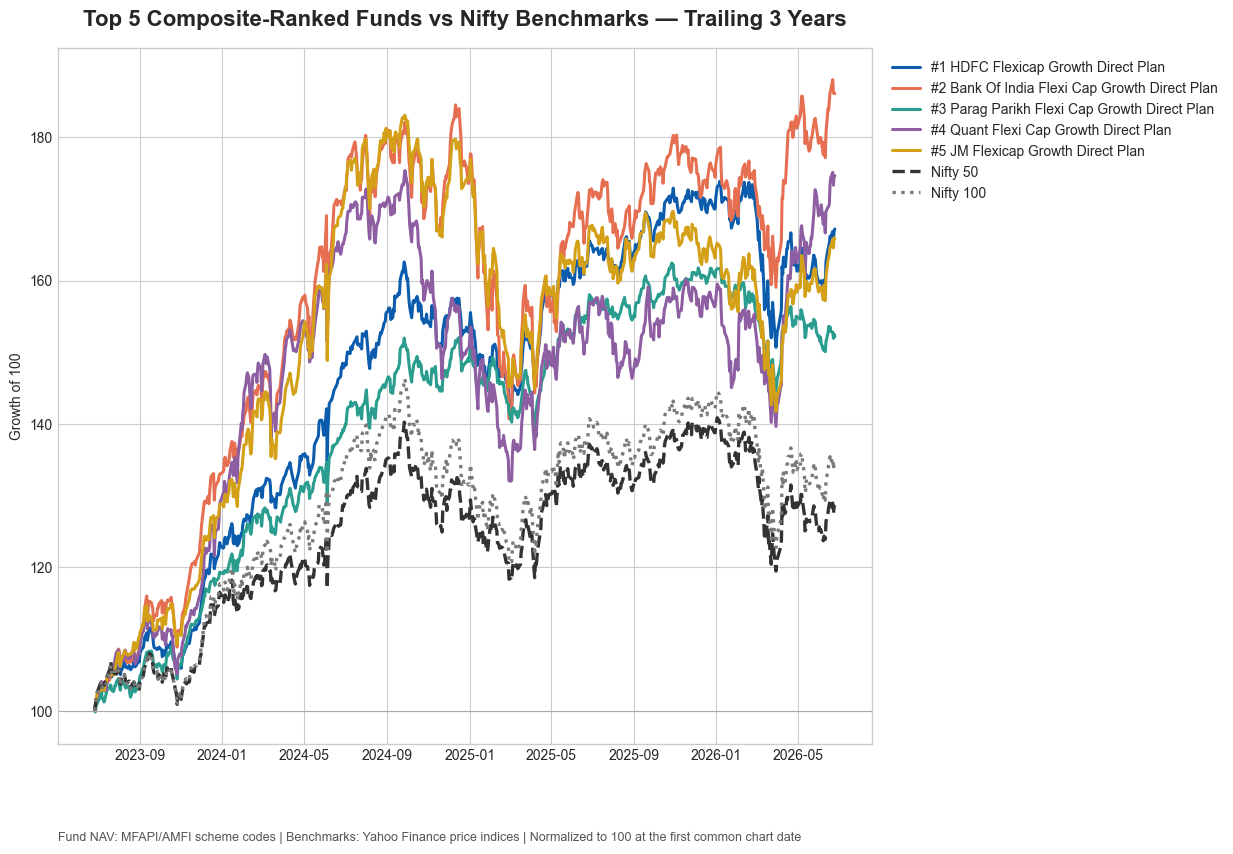

,overall_rank,scheme_name,tracking_error_nifty50_pct,tracking_error_nifty100_pct
0,1,HDFC Flexicap Growth Direct Plan,4.0504,4.0595
1,2,Bank Of India Flexi Cap Growth Direct Plan,10.3687,9.0392
2,3,Parag Parikh Flexi Cap Growth Direct Plan,6.7130,6.8487
3,4,Quant Flexi Cap Growth Direct Plan,9.4417,8.2688
4,5,JM Flexicap Growth Direct Plan,7.9751,6.8030


In [9]:
chart_start = AS_OF_DATE - pd.DateOffset(years=3)
chart_index = pd.DatetimeIndex(
    benchmarks.loc[
        (benchmarks["benchmark"] == "Nifty 100")
        & benchmarks["date"].between(chart_start, AS_OF_DATE),
        "date"
    ].sort_values().unique()
)

normalized = pd.DataFrame(index=chart_index)
for benchmark_name in ("Nifty 50", "Nifty 100"):
    series = benchmarks.loc[
        (benchmarks["benchmark"] == benchmark_name)
        & benchmarks["date"].between(chart_start, AS_OF_DATE)
    ].set_index("date")["level"].sort_index().reindex(chart_index).ffill()
    normalized[benchmark_name] = series / series.dropna().iloc[0] * 100

top_five = scorecard.head(5)[["scheme_code", "scheme_name", "overall_rank"]]
for row in top_five.itertuples(index=False):
    series = nav_history.loc[
        (nav_history["scheme_code"] == row.scheme_code)
        & nav_history["date"].between(chart_start - pd.Timedelta(days=7), AS_OF_DATE)
    ].set_index("date")["nav"].sort_index().reindex(chart_index).ffill()
    first_valid = series.first_valid_index()
    series = series.loc[first_valid:]
    normalized[f"#{row.overall_rank} {row.scheme_name}"] = series / series.dropna().iloc[0] * 100

fund_colors = ["#0B5CAD", "#E76F51", "#2A9D8F", "#8E5EA2", "#D4A017"]
fig, ax = plt.subplots(figsize=(16, 9))
for idx, row in enumerate(top_five.itertuples(index=False)):
    label = f"#{row.overall_rank} {row.scheme_name}"
    ax.plot(normalized.index, normalized[label], linewidth=2.2, color=fund_colors[idx], label=label)
ax.plot(normalized.index, normalized["Nifty 50"], linewidth=2.4, linestyle="--", color="#333333", label="Nifty 50")
ax.plot(normalized.index, normalized["Nifty 100"], linewidth=2.4, linestyle=":", color="#7A7A7A", label="Nifty 100")
ax.axhline(100, color="#AAAAAA", linewidth=0.8)
ax.set_title("Top 5 Composite-Ranked Funds vs Nifty Benchmarks — Trailing 3 Years", fontsize=16, weight="bold", pad=16)
ax.set_ylabel("Growth of 100")
ax.set_xlabel("")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
ax.text(
    0, -0.14,
    "Fund NAV: MFAPI/AMFI scheme codes | Benchmarks: Yahoo Finance price indices | Normalized to 100 at the first common chart date",
    transform=ax.transAxes, fontsize=9, color="#555555"
)
fig.tight_layout(rect=[0, 0.04, 0.78, 1])
fig.savefig(CHART_PATH, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

top_five_tracking = scorecard.head(5)[[
    "overall_rank", "scheme_name", "tracking_error_nifty50_pct", "tracking_error_nifty100_pct"
]]
display(top_five_tracking)


## 7. Deliverable validation

In [10]:
scorecard_check = pd.read_csv(SCORECARD_PATH)
alpha_beta_check = pd.read_csv(ALPHA_BETA_PATH)

validation = pd.DataFrame({
    "check": [
        "Scorecard contains 40 unique funds",
        "Alpha/beta contains 40 unique funds",
        "No missing core score inputs",
        "Scores fall within 0-100",
        "All ranks are unique 1-40",
        "Benchmark chart exists and is non-empty",
        "Daily return distributions cover all 40 funds",
    ],
    "passed": [
        len(scorecard_check) == 40 and scorecard_check["scheme_code"].nunique() == 40,
        len(alpha_beta_check) == 40 and alpha_beta_check["scheme_code"].nunique() == 40,
        not scorecard_check[["cagr_3y_pct", "sharpe_ratio", "alpha_annual_pct", "expense_ratio_pct", "max_drawdown_pct"]].isna().any().any(),
        scorecard_check["fund_score"].between(0, 100).all(),
        set(scorecard_check["overall_rank"]) == set(range(1, 41)),
        CHART_PATH.exists() and CHART_PATH.stat().st_size > 10_000,
        distribution_by_fund["scheme_code"].nunique() == 40,
    ],
})

assert validation["passed"].all(), validation.loc[~validation["passed"]]
display(validation)
print(f"Created: {SCORECARD_PATH.name} ({SCORECARD_PATH.stat().st_size:,} bytes)")
print(f"Created: {ALPHA_BETA_PATH.name} ({ALPHA_BETA_PATH.stat().st_size:,} bytes)")
print(f"Created: {CHART_PATH.name} ({CHART_PATH.stat().st_size:,} bytes)")


,check,passed
0,Scorecard contains 40 unique funds,True
1,Alpha/beta contains 40 unique funds,True
2,No missing core score inputs,True
3,Scores fall within 0-100,True
4,All ranks are unique 1-40,True
5,Benchmark chart exists and is non-empty,True
6,Daily return distributions cover all 40 funds,True


Created: fund_scorecard.csv (15,709 bytes)
Created: alpha_beta.csv (7,307 bytes)
Created: benchmark_comparison.png (560,050 bytes)
